# Dimensionless diaphragm chain

A row of bistable diaphragms (each can sit in a "low" or "high" state) connected by
sealed gas pockets. Squeezing one pocket pushes on its neighbour through Boyle's law
(pressure x volume = constant), so a switch can travel along the row as a wave.

Written in dimensionless form, the whole model depends on just **four** numbers:

| group | what it is |
|-------|------------|
| $\eta = \frac{A p_0}{k a^3}$   | gas pressure vs. how stiff each diaphragm is |
| $\theta = \frac{A a}{V_0}$ | how much a gas pocket's volume changes when a diaphragm switches |
| $\Pi = \frac{\delta}{a^3}$    | how lopsided the two states are - this is what drives the wave |
| $\Omega = \frac{\alpha}{a\sqrt{mk}}$ | damping |

The dimensional notebook already mapped what the raw knobs ($A, \delta, \alpha$) do one
at a time. This notebook is about the things you can only see with the dimensionless groups:

- **same groups means same wave** - two builds with completely different raw numbers behave identically
- **a validity map for the wave-speed formula** - the 10% bounds asked once, in group form, for every build
- **where the wave stops moving at all** - weak coupling narrows the front until the lattice
  traps it, a threshold the continuum description cannot produce
- **an open question: gas vs spring** - Boyle's law is lopsided where a linear spring is not,
  and it shows: mirrored waves pick up a small speed difference that no spring chain can have

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from IPython.display import display, Markdown

# the four dimensionless groups (canonical values)
eta   = 80.0    # gas pressure / diaphragm stiffness
theta = 0.1     # volume change per switch
Pi    = 0.115   # asymmetry between the two states (drives the wave)
Omega = 10.0    # damping

# cached sweep results: load from CSV when present, or set True to recompute
CSV_DIR     = 'results'
FORCE_RERUN = False


In [2]:
def wells(Pi):
    """The three rest states: roots of  u^3 - u + Pi = 0,  sorted low < mid < high."""
    r = np.sort(np.roots([1, 0, -1, Pi]).real)
    return r[0], r[1], r[2]

def gas_force(u, eta, theta):
    """Boyle-law pressure force on each diaphragm."""
    p = 1.0 / (1.0 + theta * (u[1:] - u[:-1]))     # 1 / volume of each gas pocket
    F = np.zeros_like(u)
    F[1:-1] = eta * (p[:-1] - p[1:])
    return F

def energy(u, v, eta, theta, Pi):
    """Total energy: motion + the double-well + the gas."""
    gaps = 1.0 + theta * (u[1:] - u[:-1])
    well = u**4/4 - u**2/2 + Pi*u
    return 0.5*np.sum(v**2) + np.sum(well) - (eta/theta)*np.sum(np.log(gaps))

def front_speed(frames, times, u_lo, u_hi, flip=False):
    """Track where the wave front is in each frame and fit its speed."""
    N = frames.shape[1]
    mid = 0.5*(u_lo + u_hi)
    pos = []
    for f in frames:
        sel = np.where(f < mid)[0] if not flip else np.where(f > mid)[0]
        if len(sel) == 0:
            pos.append(0.0)
        elif sel[-1] + 1 >= N:
            pos.append(float(sel[-1]))
        else:
            i = sel[-1]
            pos.append(i + (f[i] - mid) / (f[i] - f[i+1]))   # sub-diaphragm crossing
    pos = np.array(pos)
    half = times > 0.5*times[-1]                             # steady half only
    return (np.polyfit(times[half], pos[half], 1)[0] if half.sum() > 2 else np.nan), pos

def run(eta, theta, Pi, Omega, N=120, T=150.0, dt=None,
        n_sponge=10, sponge=4.0, n_trigger=5, save_every=200,
        track_energy=False, flip=False):
    """
    Integrate the chain and return the wave.

    Normally the left end is held low and the rest starts high; the boundary travels
    right as a wave. With flip=True the roles swap (left end high, rest low), which
    runs the mirrored wave. Returns a dict with frames, times, wave position and
    speed, or {'error': ...} if a gas pocket collapses.
    """
    if dt is None:
        dt = 0.05 / max(np.sqrt(2 + 4*abs(eta*theta)), Omega)
    u_lo, _, u_hi = wells(Pi)
    bg, trig = (u_hi, u_lo) if not flip else (u_lo, u_hi)

    # a little extra damping near the walls so the wave is absorbed, not reflected
    damp = np.full(N, float(Omega))
    if n_sponge > 0:
        ramp = sponge * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, bg); u[:n_trigger] = trig
    v = np.zeros(N)
    force = lambda uu: gas_force(uu, eta, theta) - (uu**3 - uu + Pi)

    steps = int(T / dt)
    frames, E = [], []
    a = force(u) - damp*v
    for step in range(steps):
        u += v*dt + 0.5*a*dt**2
        u[:n_trigger] = trig; u[-1] = bg
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        if step > steps//10 and np.min(1 + theta*(u[1:]-u[:-1])) <= 0:
            return {'error': 'a gas pocket collapsed to zero volume'}
        f = force(u)
        v = (v + 0.5*dt*(a + f)) / (1 + 0.5*damp*dt)   # semi-implicit, handles damping
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a = f - damp*v
        if step % save_every == 0:
            frames.append(u.copy())
            if track_energy: E.append(energy(u, v, eta, theta, Pi))

    frames = np.array(frames)
    times  = np.arange(len(frames)) * save_every * dt
    speed, pos = front_speed(frames, times, u_lo, u_hi, flip=flip)

    out = {'frames': frames, 'times': times, 'pos': pos, 'speed': speed,
           'u_lo': u_lo, 'u_hi': u_hi}
    if track_energy: out['energy'] = np.array(E)
    return out

## A travelling wave

Hold the left end low and the right end high. The boundary between them moves along
the chain as a switching wave. Below it is shown at four moments in time. This is simply verifying what was shown in the dimensional notebook already.

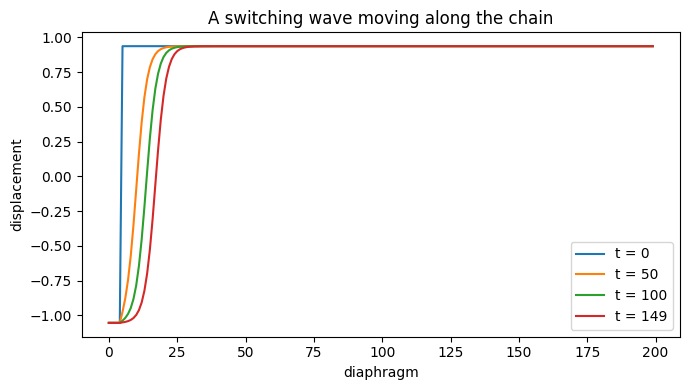

wave speed: 0.069 diaphragms per unit time


In [3]:
r = run(eta, theta, Pi, Omega, N=200, T=150)
sites = np.arange(r['frames'].shape[1])

plt.figure(figsize=(7, 4))
idx = [0, len(r['frames'])//3, 2*len(r['frames'])//3, len(r['frames'])-1]
for i in idx:
    plt.plot(sites, r['frames'][i], label=f"t = {r['times'][i]:.0f}")
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('A switching wave moving along the chain')
plt.legend(); plt.tight_layout(); plt.show()

print(f"wave speed: {r['speed']:.3f} diaphragms per unit time")

## Same groups, same wave

Build two completely different physical systems - different masses, stiffnesses and
pressures - but chosen to share the same four non-dimensional groups by scaling choices. They produce the
exact same wave. This is the foundation everything else rests on.

  system A:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
  system B:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
biggest difference between the three runs: 1.0e-14


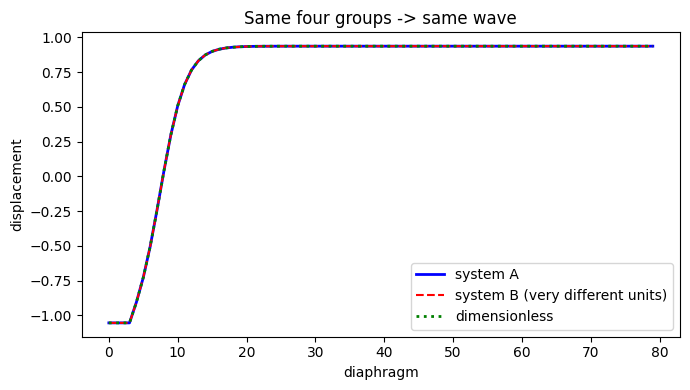

In [4]:
def dimensional_from_groups(eta, theta, Pi, Omega, m, k, a, A):
    """Physical parameters that reproduce the four groups (m, k, a, A are free choices)."""
    return dict(m=m, k=k, a=a, A=A,
                p0=eta*k*a**3/A, V0=A*a/theta, delta=Pi*a**3, alpha=Omega*a*np.sqrt(m*k))

def groups_from_dimensional(p):
    """Go the other way: recover (eta, theta, Pi, Omega) from physical parameters."""
    return (p['A']*p['p0']/(p['k']*p['a']**3), p['A']*p['a']/p['V0'],
            p['delta']/p['a']**3, p['alpha']/(p['a']*np.sqrt(p['m']*p['k'])))

def run_dimensional(m, A, k, p0, V0, a, delta, alpha,
                    N=80, T=60.0, dt_tilde=None, n_sponge=6, sponge=4.0,
                    n_trigger=4, save_every=100):
    """The same simulation in raw physical units. Returns (times, frames) with the
    output already rescaled, or None if a gas pocket collapses."""
    eta_ = A*p0/(k*a**3)
    Omega_ = alpha/(a*np.sqrt(m*k))
    if dt_tilde is None:
        dt_tilde = 0.05 / max(np.sqrt(2 + 4*abs(eta_*A*a/V0)), Omega_)
    T_scale = np.sqrt(m/(k*a**2))
    dt = dt_tilde * T_scale
    u_lo, _, u_hi = np.sort(np.roots([1, 0, -a**2, delta]).real)

    damp = np.full(N, float(alpha))
    if n_sponge > 0:
        ramp = sponge * a*np.sqrt(m*k) * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, u_hi); u[:n_trigger] = u_lo
    v = np.zeros(N)
    def force(uu):
        pr = p0*V0 / (V0 + A*(uu[1:] - uu[:-1]))
        F = np.zeros_like(uu); F[1:-1] = A*(pr[:-1] - pr[1:])
        return F - k*(uu**3 - a**2*uu + delta)

    steps = int(T*T_scale / dt)
    hist, acc = [], (force(u) - damp*v) / m
    for step in range(steps):
        u += v*dt + 0.5*acc*dt**2
        u[:n_trigger] = u_lo; u[-1] = u_hi; v[:n_trigger] = 0; v[-1] = 0
        if step > steps//10 and np.min(V0 + A*(u[1:] - u[:-1])) <= 0:
            return None                                    # pocket collapsed
        f = force(u)
        v = (v + 0.5*dt*(acc + f/m)) / (1 + 0.5*damp*dt/m)
        v[:n_trigger] = 0; v[-1] = 0
        acc = (f - damp*v) / m
        if step % save_every == 0:
            hist.append(u / a)              # divide by length scale -> same units as run()
    return np.arange(len(hist)) * save_every * dt_tilde, np.array(hist)

# two genuinely different physical builds, both tuned to the same four groups
A_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=1.0,  k=1.0,   a=1.0,  A=1.0)
B_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=3e-3, k=250.0, a=0.02, A=5e-4)

for name, p in [('system A', A_sys), ('system B', B_sys)]:
    e, t, pi, om = groups_from_dimensional(p)
    print(f"  {name}:  eta={e:.2f}   theta={t:.3f}   Pi={pi:.4f}   Omega={om:.3f}")

# run both physical systems and the dimensionless one; they should coincide
dt0 = 0.05 / max(np.sqrt(2 + 4*eta*theta), Omega)
kw  = dict(N=80, T=60.0, dt_tilde=dt0, n_sponge=6, n_trigger=4, save_every=100)
tA, hA = run_dimensional(**A_sys, **kw)
tB, hB = run_dimensional(**B_sys, **kw)
hD = run(eta, theta, Pi, Omega, N=80, T=60.0, dt=dt0,
         n_sponge=6, n_trigger=4, save_every=100)['frames']

n    = min(len(hA), len(hB), len(hD))
diff = max(np.max(np.abs(hA[:n]-hB[:n])), np.max(np.abs(hA[:n]-hD[:n])))
print(f"biggest difference between the three runs: {diff:.1e}")

mid = n // 2
plt.figure(figsize=(7, 4))
plt.plot(hA[mid], 'b-',  lw=2,   label='system A')
plt.plot(hB[mid], 'r--', lw=1.5, label='system B (very different units)')
plt.plot(hD[mid], 'g:',  lw=2,   label='dimensionless')
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('Same four groups -> same wave'); plt.legend(); plt.tight_layout(); plt.show()

## Check: the simulation is sound

Turn the damping off ($\Omega = 0$). With no damping the total energy should stay flat -
a basic check that the integrator is behaving and not quietly adding or losing energy.

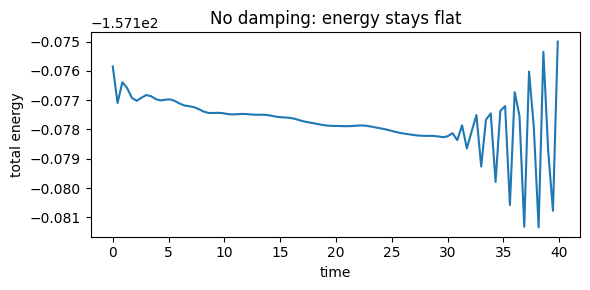

largest energy drift: 3.5e-05


In [5]:
r0 = run(eta, theta, Pi, 0.0, N=80, T=40, n_sponge=0, n_trigger=4,
         save_every=50, track_energy=True)
E = r0['energy']
drift = np.max(np.abs((E - E[0]) / abs(E[0])))

plt.figure(figsize=(6, 3))
plt.plot(r0['times'][:len(E)], E)
plt.xlabel('time'); plt.ylabel('total energy')
plt.title('No damping: energy stays flat'); plt.tight_layout(); plt.show()

print(f"largest energy drift: {drift:.1e}")

## Where does the speed formula hold, in group language?

The dimensional notebook measured, knob by knob, where the energy-balance
prediction (speed = energy released / damping x gradient integral) stays within
10% of the true speed. Those bounds were tied to the one build they were
measured on. Asking the question in groups answers it once, for every build:
sweep each group with the other three held at their canonical values, and shade
where the prediction is within 10%.

What the sweeps show, at this slice: damping is the key dial. Once the
chain is safely overdamped the formula tolerates almost everything else - drive
right up to the boundary, coupling far below its canonical value, any $\theta$.
Push $\Omega$ below $\sim 0.2$ and it fails fast, and it keeps getting worse the lower
$\Omega$ goes.

That breakdown is real, not a measurement artefact. The dimensional notebook tests the
same limit head-on at low $\alpha$: sizing the lattice to the (fast) underdamped speed so
the front stays in the bulk, then measuring the ratio in successive time windows. It comes
out flat - unchanged even after the ringing has completely decayed - and grows steadily as
damping falls. The reason is that the energy-balance formula *is* the overdamped limit: it
assumes the drive energy all goes into damping, so as $\Omega \to 0$ it ignores an
ever-larger share of the physics (the front's own inertia, and the lattice waves it
radiates). Same effect in both notebooks, in different coordinates.

This also explains the dimensional notebook's $\delta$ and $A$ bounds: they were
measured at $\Omega \sim 0.33$, close to the fragile edge, where the other dials
still matter. Deep in the overdamped regime both constraints dissolve.

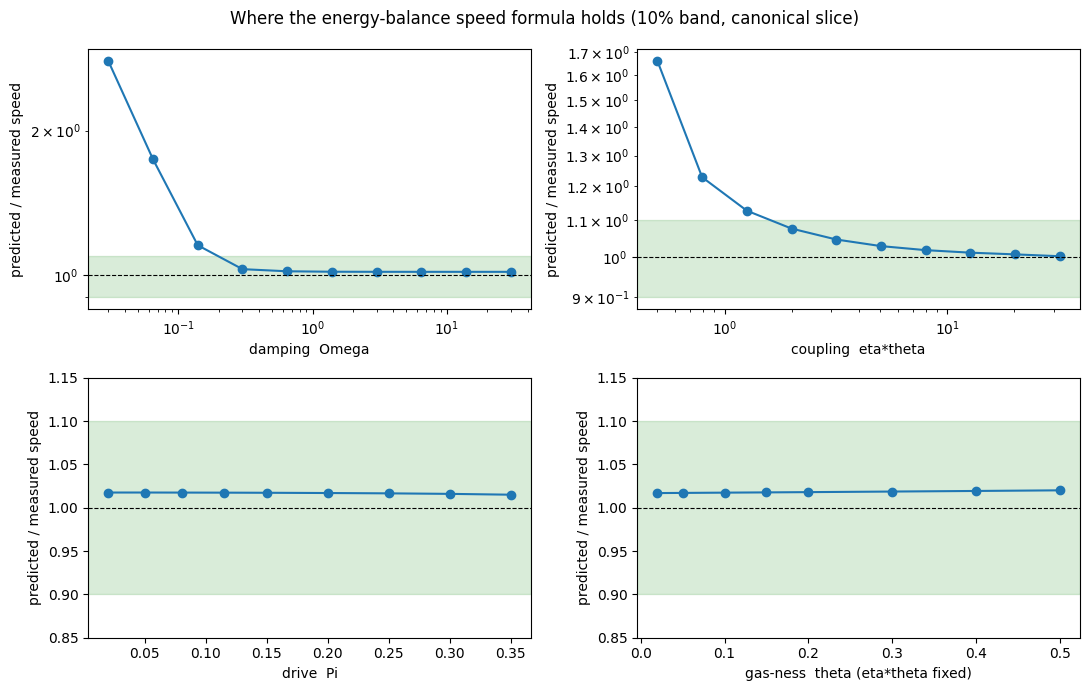

Omega:     within 10% for Omega >~ 0.20
eta*theta: within 10% for eta*theta >~ 1.6
Pi:        worst error 1.7%
theta:     worst error 2.0%


In [6]:
# One sweep per group, others at canonical (eta*theta=8, theta=0.1, Pi=0.115, Omega=10).
# Run times are matched to each wave's speed so the front crosses enough lattice
# for a clean fit; the underdamped sweep gets a longer lattice (fast fronts).

def arrieta_ratio(res, Pi_v, Omega_v):
    """Predicted / measured speed; prediction from the mid-run front profile."""
    snap = res['frames'][len(res['frames'])//2]
    integral = np.sum(np.gradient(snap)**2)
    psi = lambda u: u**4/4 - u**2/2 + Pi_v*u
    v_pred = (psi(res['u_hi']) - psi(res['u_lo'])) / (Omega_v * integral)
    return v_pred / res['speed']

def measure(eta_v, theta_v, Pi_v, Omega_v, T, N=150):
    res = run(eta_v, theta_v, Pi_v, Omega_v, N=N, T=T, save_every=200)
    if 'error' in res or not np.isfinite(res.get('speed', np.nan)) or res['speed'] < 1e-4:
        return np.nan
    return arrieta_ratio(res, Pi_v, Omega_v)

Om_vals = np.geomspace(0.03, 30, 10)
r_Om = [measure(eta, theta, Pi, Om, T=(100.0 if Om < 1 else min(40.0*Om, 1200.0)), N=300)
        for Om in Om_vals]

et_vals = np.geomspace(0.5, 32, 10)
r_et = [measure(et/theta, theta, Pi, Omega, T=float(np.clip(1200/np.sqrt(et), 150, 1800)))
        for et in et_vals]

Pi_vals = np.array([0.02, 0.05, 0.08, 0.115, 0.15, 0.20, 0.25, 0.30, 0.35])
r_Pi = [measure(eta, theta, p, Omega, T=float(np.clip(58/p, 200, 1500))) for p in Pi_vals]

th_vals = np.array([0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])
r_th = [measure(8/t, t, Pi, Omega, T=500.0) for t in th_vals]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [(axes[0,0], Om_vals, r_Om, 'damping  Omega',        'log', 'log'),
          (axes[0,1], et_vals, r_et, 'coupling  eta*theta',   'log', 'log'),
          (axes[1,0], Pi_vals, r_Pi, 'drive  Pi',             'linear', 'linear'),
          (axes[1,1], th_vals, r_th, 'gas-ness  theta (eta*theta fixed)', 'linear', 'linear')]
for ax, x, r, lab, xs, ys in panels:
    ax.axhspan(0.9, 1.1, color='green', alpha=0.15, label='within 10%')
    ax.plot(x, r, 'o-')
    ax.axhline(1.0, color='k', lw=0.8, ls='--')
    ax.set_xscale(xs); ax.set_yscale(ys)
    ax.set_xlabel(lab); ax.set_ylabel('predicted / measured speed')
    if ys == 'linear': ax.set_ylim(0.85, 1.15)
plt.suptitle('Where the energy-balance speed formula holds (10% band, canonical slice)')
plt.tight_layout(); plt.show()

# thresholds: where |ratio - 1| crosses 0.10 (log-interpolated on the swept axis)
def threshold(x, r):
    x, r = np.asarray(x, float), np.asarray(r, float)
    for i in range(len(x) - 1):
        a, b = abs(r[i]-1) - 0.1, abs(r[i+1]-1) - 0.1
        if a > 0 >= b:
            f = a / (a - b)
            return float(np.exp(np.log(x[i]) + f*(np.log(x[i+1]) - np.log(x[i]))))
    return np.nan

Om_thr, et_thr = threshold(Om_vals, r_Om), threshold(et_vals, r_et)
print(f"Omega:     within 10% for Omega >~ {Om_thr:.2f}")
print(f"eta*theta: within 10% for eta*theta >~ {et_thr:.1f}")
print(f"Pi:        worst error {100*max(abs(r-1) for r in r_Pi):.1f}%")
print(f"theta:     worst error {100*max(abs(r-1) for r in r_th):.1f}%")

## Where the wave stops moving at all

The validity map asks where the *speed formula* fails. A sharper question is where the wave
fails to move at all — and two things make the answer non-obvious.

First, **weakening the drive does not stop it.** The dimensional notebook takes the drive down
by two decades and finds the speed falls smoothly in proportion, $v \propto \delta$, with no
threshold anywhere. Second, **the continuum balance can never give exactly zero**: from
$v = \Delta\Psi / (\Omega\!\int\! U'^2 d\xi)$, weakening the coupling steepens the front, which
grows the integral, which sends $v$ towards zero *asymptotically* — approaching it without
ever arriving. So if a hard threshold exists, it cannot come from the continuum description at
all. It has to be a property of the lattice.

**The front width sets the scale.** In the wide-front limit the gas acts as a spring chain of
stiffness $\eta\theta$, and balancing that stiffness against the double well gives a $\tanh$
profile of width

$$w = \sqrt{2\,\eta\theta}$$

measured in lattice spacings. This is the quantity that decides how much of the lattice the
front can see. A wide front spreads over many diaphragms and averages the discreteness away; a
narrow one sits on one or two sites and feels each of them individually. The residual
site-to-site corrugation a kink must climb — the **Peierls–Nabarro barrier** — falls roughly
*exponentially* as $w$ grows. That is why a wide front will propagate under almost any drive,
and why a narrow one may not propagate at all.

Which gives a prediction to test: shrink $\eta\theta$ at fixed drive, narrowing the front, and
the wave should eventually pin — with the threshold set by a competition between the drive and
a barrier that is exponential in $w$.

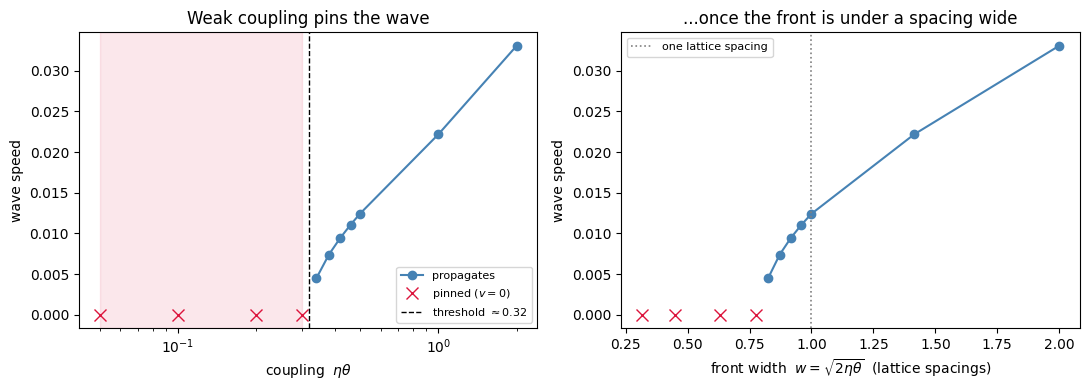


**The wave pins below a coupling threshold.** The speed falls steadily with $\eta\theta$ and
then stops dead between $\eta\theta = 0.30$ and $0.34$, i.e. a front width
between 0.775 and 0.825 lattice spacings. The last
propagating point still moves at a finite $v = 0.00447$, so the arrest is abrupt
at this resolution.

**It is genuinely pinned, not creeping.** Re-running the first pinned point at
$T = 1500 / 6000 / 30000$ leaves the front at an identical position
(5.587 / 5.587 / 5.587) with the fitted speed at machine zero
(4.5e-20 to 5.7e-11) — a $20\times$ span of run
time and the front has not advanced at all. This is the check that distinguishes a pinned
front from a very slow one.


In [7]:
# ── Does the wave pin when the coupling gets weak? ───────────────────────────
#
# Sweep eta*theta down at canonical drive and measure the speed. The companion
# check matters as much as the sweep: a front creeping at v ~ 1e-4 looks pinned in
# a finite run, so at the first pinned point we re-run at 4x and 20x the time and
# confirm the front sits at an IDENTICAL position (v at machine zero => frozen).
# Cached: the low-coupling runs need T up to 6000 (a few minutes total).

CSV_PIN  = os.path.join(CSV_DIR, 'pinning_vs_coupling.csv')
CSV_PINT = os.path.join(CSV_DIR, 'pinning_finiteT.csv')

def _sweep_coupling(et, T):
    r = run(et/theta, theta, Pi, Omega, N=200, T=float(T), save_every=1000)
    if 'error' in r: return None
    return dict(eta_theta=et, T=T, v_sim=max(r['speed'], 0.0),
                moved=r['pos'][-1]-r['pos'][0], width=np.sqrt(2*et))

if not FORCE_RERUN and os.path.exists(CSV_PIN):
    df_pin = pd.read_csv(CSV_PIN)
else:
    grid = [(2.0, 2121), (1.0, 3000), (0.50, 5000), (0.46, 5000), (0.42, 5000),
            (0.38, 5000), (0.34, 5000), (0.30, 5000), (0.20, 6000), (0.10, 6000), (0.05, 6000)]
    rows = [_sweep_coupling(et, T) for et, T in grid]
    df_pin = pd.DataFrame([r for r in rows if r])
    df_pin['propagates'] = (df_pin.moved > 5).astype(int)
    df_pin.to_csv(CSV_PIN, index=False);  print(f"Saved -> {CSV_PIN}")

if not FORCE_RERUN and os.path.exists(CSV_PINT):
    df_pinT = pd.read_csv(CSV_PINT)
else:
    rows = []
    for T in (1500, 6000, 30000):
        r = run(0.30/theta, theta, Pi, Omega, N=200, T=float(T), save_every=1000)
        rows.append(dict(T=T, front_end=r['pos'][-1], v_fit=r['speed']))
    df_pinT = pd.DataFrame(rows);  df_pinT.to_csv(CSV_PINT, index=False)
    print(f"Saved -> {CSV_PINT}")

prop = df_pin[df_pin.propagates == 1].sort_values('eta_theta')
pinned = df_pin[df_pin.propagates == 0].sort_values('eta_theta')
et_hi = prop.eta_theta.min()          # slowest surviving front
et_lo = pinned.eta_theta.max()        # fastest pinned point

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(prop.eta_theta, prop.v_sim, 'o-', color='steelblue', label='propagates')
ax1.plot(pinned.eta_theta, pinned.v_sim, 'x', ms=9, color='crimson', label='pinned ($v=0$)')
ax1.axvspan(df_pin.eta_theta.min(), et_lo, color='crimson', alpha=0.10)
ax1.axvline(np.sqrt(et_lo*et_hi), color='k', ls='--', lw=1,
            label=rf'threshold $\approx{np.sqrt(et_lo*et_hi):.2f}$')
ax1.set_xscale('log'); ax1.set_xlabel(r'coupling  $\eta\theta$')
ax1.set_ylabel('wave speed'); ax1.set_title('Weak coupling pins the wave')
ax1.legend(fontsize=8)

ax2.plot(prop.width, prop.v_sim, 'o-', color='steelblue')
ax2.plot(pinned.width, pinned.v_sim, 'x', ms=9, color='crimson')
ax2.axvline(1.0, color='gray', ls=':', lw=1.2, label='one lattice spacing')
ax2.set_xlabel(r'front width  $w=\sqrt{2\eta\theta}$  (lattice spacings)')
ax2.set_ylabel('wave speed'); ax2.set_title('...once the front is under a spacing wide')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/pinning_vs_coupling.png', dpi=120, bbox_inches='tight')
plt.show()

_ft = " / ".join(f"{p:.3f}" for p in df_pinT.front_end)
display(Markdown(f"""
**The wave pins below a coupling threshold.** The speed falls steadily with $\\eta\\theta$ and
then stops dead between $\\eta\\theta = {et_lo:.2f}$ and ${et_hi:.2f}$, i.e. a front width
between {np.sqrt(2*et_lo):.3f} and {np.sqrt(2*et_hi):.3f} lattice spacings. The last
propagating point still moves at a finite $v = {prop.v_sim.min():.5f}$, so the arrest is abrupt
at this resolution.

**It is genuinely pinned, not creeping.** Re-running the first pinned point at
$T = {' / '.join(str(int(t)) for t in df_pinT["T"])}$ leaves the front at an identical position
({_ft}) with the fitted speed at machine zero
({df_pinT.v_fit.abs().min():.1e} to {df_pinT.v_fit.abs().max():.1e}) — a $20\\times$ span of run
time and the front has not advanced at all. This is the check that distinguishes a pinned
front from a very slow one.
"""))

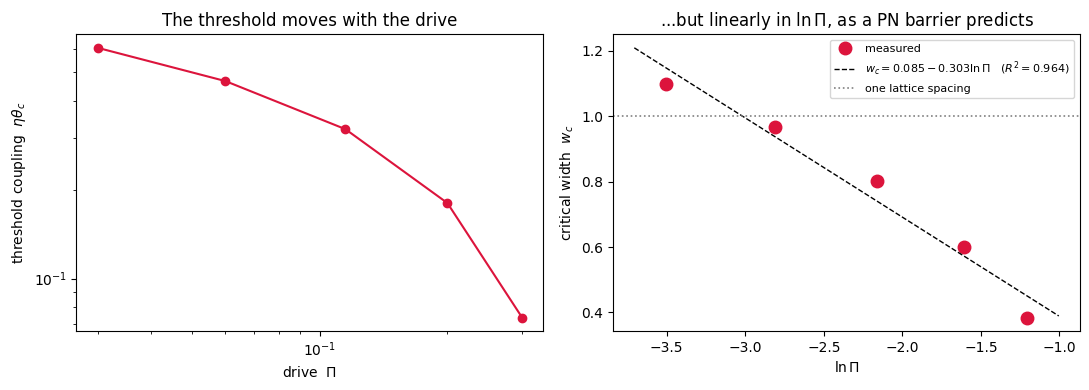


**There is no single critical width.** Across a 10$\times$
range of drive, the threshold width runs from 0.384 to 1.100 lattice
spacings — a factor of 2.9. So "the front is narrower than a lattice
spacing" is *not* the criterion: at weak drive a 1.10-spacing front pins, while at
strong drive a 0.38-spacing front still runs.

**What does hold is the Peierls-Nabarro form.** The critical width is linear in $\ln\Pi$,

$$w_c = 0.085 -0.303\,\ln\Pi, \qquad R^2 = 0.964,$$

against $R^2 = 0.876$ for a pure power law $w_c \sim \Pi^{-0.43}$. A barrier
falling exponentially with width, set against a drive $\Pi$, gives exactly this logarithm.

Taken with the previous cell the picture is consistent: the arrest is a lattice effect — the
continuum balance sends $v \to 0$ only asymptotically and can never produce a hard threshold —
and its location is fixed by the drive competing against a barrier exponential in the front
width, not by the width crossing any particular value.


In [8]:
# ── Is the threshold set by the width, or by the drive? ──────────────────────
#
# The width alone would predict a single critical w. Peierls-Nabarro instead predicts
# a competition: barrier ~ exp(-c*w) against drive Pi, so depinning at
#   Pi ~ exp(-c*w_c)   =>   w_c linear in ln(Pi)
# Bisect for the threshold at each Pi and test that form.
# Cached: 5 bisections x 7 runs, with T up to 12000 (~70 min).
# Regenerate with:  python3 scripts/pinning_boundary.py

CSV_BND = os.path.join(CSV_DIR, 'pinning_boundary.csv')
df_bnd = pd.read_csv(CSV_BND)          # see scripts/pinning_boundary.py to rebuild

lnPi = np.log(df_bnd.Pi.values);  wc = df_bnd.width_c.values
sl, ic = np.polyfit(lnPi, wc, 1)
r2_log = 1 - np.sum((wc - (sl*lnPi+ic))**2)/np.sum((wc - wc.mean())**2)
slp, icp = np.polyfit(lnPi, np.log(wc), 1)
r2_pow = 1 - np.sum((wc - np.exp(slp*lnPi+icp))**2)/np.sum((wc - wc.mean())**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.loglog(df_bnd.Pi, df_bnd.eta_theta_c, 'o-', color='crimson')
ax1.set_xlabel(r'drive  $\Pi$'); ax1.set_ylabel(r'threshold coupling  $\eta\theta_c$')
ax1.set_title('The threshold moves with the drive')

_x = np.linspace(lnPi.min()-0.2, lnPi.max()+0.2, 50)
ax2.plot(lnPi, wc, 'o', ms=9, color='crimson', label='measured')
ax2.plot(_x, sl*_x + ic, 'k--', lw=1,
         label=rf'$w_c = {ic:.3f} {sl:+.3f}\ln\Pi$   ($R^2={r2_log:.3f}$)')
ax2.axhline(1.0, color='gray', ls=':', lw=1.2, label='one lattice spacing')
ax2.set_xlabel(r'$\ln \Pi$'); ax2.set_ylabel(r'critical width  $w_c$')
ax2.set_title('...but linearly in $\\ln\\Pi$, as a PN barrier predicts')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/pinning_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

display(Markdown(f"""
**There is no single critical width.** Across a {df_bnd.Pi.max()/df_bnd.Pi.min():.0f}$\\times$
range of drive, the threshold width runs from {wc.min():.3f} to {wc.max():.3f} lattice
spacings — a factor of {wc.max()/wc.min():.1f}. So "the front is narrower than a lattice
spacing" is *not* the criterion: at weak drive a {wc.max():.2f}-spacing front pins, while at
strong drive a {wc.min():.2f}-spacing front still runs.

**What does hold is the Peierls-Nabarro form.** The critical width is linear in $\\ln\\Pi$,

$$w_c = {ic:.3f} {sl:+.3f}\\,\\ln\\Pi, \\qquad R^2 = {r2_log:.3f},$$

against $R^2 = {r2_pow:.3f}$ for a pure power law $w_c \\sim \\Pi^{{{slp:.2f}}}$. A barrier
falling exponentially with width, set against a drive $\\Pi$, gives exactly this logarithm.

Taken with the previous cell the picture is consistent: the arrest is a lattice effect — the
continuum balance sends $v \\to 0$ only asymptotically and can never produce a hard threshold —
and its location is fixed by the drive competing against a barrier exponential in the front
width, not by the width crossing any particular value.
"""))

## An open question: the gas is not just a spring

Boyle's law is lopsided in a way a spring is not. Squeeze a pocket to half its volume and
its pressure **doubles**; stretch it to twice its volume and its pressure only **halves**.
Equal and opposite volume changes do not give equal and opposite pressure changes - the
push-back from squeezing beats the pull-back from stretching. A linear spring has no such
asymmetry: $F = -kx$ treats compression and extension as exact mirrors.

Does that asymmetry survive into the wave? A wave can pass in two mirrored ways: one
**squeezes** each pocket as it arrives, the other **stretches** it. With spring coupling the
two are mirror images and must run at identical speeds - so any gap at all between them is
something a spring chain cannot produce. With gas, the squeezing wave gets more help than
the stretching wave loses, so it should run slightly faster, by a margin that grows with
$\theta$ and vanishes as $\theta \to 0$, where the pockets are so large that Boyle's curve is
locally straight. (The mirrored wave = flip the sign of $\Pi$ and start from the opposite
state.)

Write $\Delta_n = \tilde u_{n+1} - \tilde u_n$ for the strain of
pocket $n$, so its volume is $\tilde V_n = 1 + \theta \Delta_n$. The gas force on diaphragm $n$
is the pressure difference across it; putting the two fractions over a common denominator is
exact, nothing expanded:

$$F_n \;=\; \eta\left[\frac{1}{\tilde V_{n-1}} - \frac{1}{\tilde V_n}\right]
      \;=\; \frac{\eta\,\theta\,\left(\Delta_n - \Delta_{n-1}\right)}{\tilde V_{n-1}\,\tilde V_n}.$$

Since $\Delta_n - \Delta_{n-1} = \tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}$ is the discrete
Laplacian - precisely the force a chain of ordinary springs would exert - the gas force
factorises into

$$F_n \;=\; \underbrace{\eta\theta}_{\text{spring stiffness}}
\;\times\; \underbrace{\left(\tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}\right)}_{\text{spring-chain force}}
\;\times\; \underbrace{\frac{1}{\tilde V_{n-1}\tilde V_n}}_{\text{Boyle correction}}.$$

Two things follow, and between them they are the whole design of the experiment below.

**First, why $\eta \, \theta$ is the right thing to hold fixed.** It is the first factor: $\eta \, \theta$
literally *is* the gas's spring stiffness. Holding it fixed freezes the spring-like part of
the coupling and leaves $\theta$ dialling the remaining nonlinearity alone. Sweeping $\theta$ at
fixed $\eta$ instead would swing the wave speed several-fold, and the gap - which is a
percentage of that speed - would be uninterpretable. That the control works is visible in the
plot: each curve stays within a few percent across the whole sweep, so the underlying wave
really is held still while $\theta$ varies.

**Second, the asymmetry is in the last factor.** A squeezed pocket has $\tilde V < 1$, so the
denominator shrinks and the force is *enhanced*; a stretched pocket has $\tilde V > 1$ and the
force is *reduced*. That is the squeeze/stretch gap, read straight off the identity - and
since the correction depends on $\theta$ only through $\theta\Delta_n$, it switches off as
$\theta \to 0$, exactly as the intuitive argument said.

The gap is real and it is not tiny: $2.6\%$ at the canonical $\theta = 0.1$, rising to
$10.8\%$ by $\theta = 0.4$. It is also close to **linear in $\theta$** - the ratio gap$/\theta$
stays between $0.25$ and $0.27$ across a 20-fold change in $\theta$ - which is what the identity predicts,
since the Boyle correction enters only through $\theta\Delta_n$ and so acts at first order in
$\theta$. A spring chain gives identically zero at every point. **Whether it is worth pursuing
is an open question**: does the asymmetry keep growing at larger $\theta$ or saturate, and is a
direction-dependent wave speed something a real metafluid could be designed around? Worth
putting to supervisors before spending time on it.

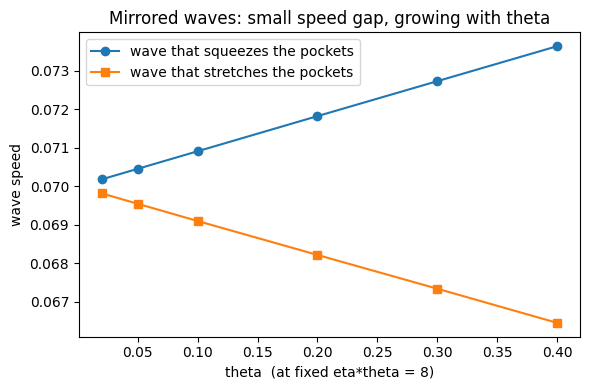

theta   squeeze   stretch   gap
0.02    0.0702    0.0698   +0.5%
0.05    0.0705    0.0695   +1.3%
0.10    0.0709    0.0691   +2.6%
0.20    0.0718    0.0682   +5.3%
0.30    0.0727    0.0673   +8.0%
0.40    0.0736    0.0665   +10.8%


In [9]:
et = 8.0                                              # eta*theta held fixed
th_vals   = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4]
c_stretch = [run(et/t, t, +Pi, Omega, N=150, T=120)['speed'] for t in th_vals]
c_squeeze = [run(et/t, t, -Pi, Omega, N=150, T=120, flip=True)['speed'] for t in th_vals]

plt.figure(figsize=(6, 4))
plt.plot(th_vals, c_squeeze, 'o-', label='wave that squeezes the pockets')
plt.plot(th_vals, c_stretch, 's-', label='wave that stretches the pockets')
plt.xlabel('theta  (at fixed eta*theta = 8)'); plt.ylabel('wave speed')
plt.title('Mirrored waves: small speed gap, growing with theta')
plt.legend(); plt.tight_layout(); plt.show()

print("theta   squeeze   stretch   gap")
for t, cq, cs in zip(th_vals, c_squeeze, c_stretch):
    print(f"{t:.2f}    {cq:.4f}    {cs:.4f}   {100*(cq-cs)/cs:+.1f}%")

## Summary

Working in the four groups instead of the eight raw parameters bought four things:

1. **One model, every build** - any two physical systems with the same $\eta, \theta, \Pi, \Omega$
   produce the same wave – as expected.
2. **A validity map for the speed formula** - within 10% once safely overdamped
   ($\Omega$ above $\sim 0.2$ at this slice), tolerating drive right up to the spinodal,
   coupling far below canonical, and any $\theta$: damping is the master dial.
3. **A pinning threshold, and its origin** - shrinking $\eta \, \theta$ narrows the front as
   $w = \sqrt{2 \, \eta \, \theta}$ until the wave stops dead (verified frozen over a $20\times$ span of
   run time). There is no single critical width: it runs 0.38 to 1.10 lattice spacings across a
   tenfold change in drive. What holds is $w_c$ linear in $\ln\Pi$ ($R^2 = 0.96$) - a barrier
   exponential in width, competing against the drive. Weakening the *drive* never pins the wave
   (see the dimensional notebook); only weakening the *coupling* does.
4. **An open question - gas vs spring** - Boyle's law is asymmetric in a way a linear
   spring is not, and it shows: waves that squeeze the pockets run slightly faster than
   their stretching mirror image, which no spring chain can do. Small over this notebook's
   range, growing with $\theta$ - whether it is worth pursuing is a question for supervisors.

(The dimensional groundwork - the integrator checks, the Arrieta formula's validity region,
and the ringing physics - is in `diaphragm_metafluid.ipynb`.)